In [63]:
###Build a basic chatbot

Build a Basic Chatbot with Langgraph(GRAPH API)

In [64]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages



In [65]:
class State(TypedDict):
    #Messages have the type "list" , the add_messages function
    #in the annotation defines how this state key should be updated
    messages:Annotated[list,add_messages]





In [66]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [67]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

In [68]:
##Node Functionalityd
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [69]:
graph_builder=StateGraph(State)
##Adding node
graph_builder.add_node("llmchatbot",chatbot)
#Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#Compile the graph
graph=graph_builder.compile()

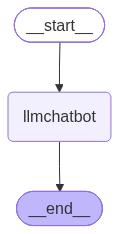

In [70]:
#Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [71]:
response=graph.invoke({"messages":"Hi this is srikar"})
response["messages"][-1].content

'Hi Srikar! How can I assist you today?'

In [72]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a computer program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?


CHAT BOT WITH TOOL CALLING

In [73]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("What is langgarph")

{'query': 'What is langgarph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [74]:
##  Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    Args:
        a(int):first int
        b(int):second int 
    returns:
        int: output int    
    """
    return a*b

In [75]:
tools=[tool,multiply]

In [76]:
llm_with_tool=llm.bind_tools(tools)

In [77]:
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16', 'langchain-openai': '1.6.0'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000131EF5FB4D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000131EF5FB9D0>, root_client=<openai.OpenAI obje

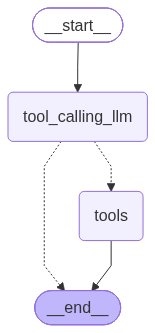

In [78]:
##state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If latest message (result) from assistant is a tool call-> tools_condition routes to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition routes to end
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [79]:
response=graph.invoke({'messages':"What is the recent AI news"})


In [80]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "## July 30, 2026\\n\\nAlgolia launched Agent Studio to help online store owners create digital shopping assistants. The system uses machine learning models to search store inventories, process customer reviews, and answer buyer questions with verified product information.\\n\\nCallRail integrated its Voice Assist software with the Clio practice management system. The tool uses natural language processing during phone calls to retrieve contact records automatically and schedule client appointments on shared calendars.\\n\\nChannel Factory launched AI Slop Detection to classify digital video content across a five-tier quality scale. The software analyzes images, audio tracks, and spoken words to flag automated, low-quality media before adver

In [81]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_ExOMreOlZ9Tibf3sF4dSBWnj)
 Call ID: call_ExOMreOlZ9Tibf3sF4dSBWnj
  Args:
    query: recent AI news
    topic: news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "## July 30, 2026\n\nAlgolia launched Agent Studio to help online store owners create digital shopping assistants. The system uses machine learning models to search store inventories, process customer reviews, and answer buyer questions with verified product information.\n\nCallRail inte

In [82]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (call_jjHru4CRxFtpR8sMSjpgsWlA)
 Call ID: call_jjHru4CRxFtpR8sMSjpgsWlA
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


ReAct Architecture

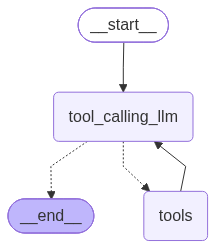

In [83]:
##state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If latest message (result) from assistant is a tool call-> tools_condition routes to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition routes to end
    tools_condition
)
##Here we are going to make changes instead going to END it again goes to Tool calling LLM
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [84]:
response=graph.invoke({"messages":"Give me the recent AI news What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_tZ8pVBJkZWghByqjlCyleFHW)
 Call ID: call_tZ8pVBJkZWghByqjlCyleFHW
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (call_UU19ZjQKusv9fGX2rJuy4SO3)
 Call ID: call_UU19ZjQKusv9fGX2rJuy4SO3
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "## July 30, 2026\n\nAlgolia launched Agent Studio to help online store owners create digital shopping assistants. The system uses machine learning model

Adding Memory in Agentic Graph

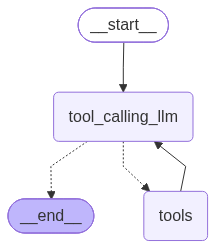

In [85]:
##state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
##Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If latest message (result) from assistant is a tool call-> tools_condition routes to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition routes to end
    tools_condition
)
##Here we are going to make changes instead going to END it again goes to Tool calling LLM
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [86]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hi my name is krish"},config=config)
response

{'messages': [HumanMessage(content='Hi my name is krish', additional_kwargs={}, response_metadata={}, id='2b3a76bb-67f4-4251-8417-3fd4d05077fe'),
  AIMessage(content='Hello Krish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 1239, 'total_tokens': 1251, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c980d3075f', 'id': 'chatcmpl-EFzaqHNr6cPQ27kpcWQ6rcRQlKcDs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02e22-3e98-7ba1-9315-554b862153f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [87]:
response['messages'][-1].content

'Hello Krish! How can I assist you today?'

In [88]:
response=graph.invoke({"messages":"What is my name"},config=config)
response['messages'][-1].content

'Your name is Krish. How can I help you today?'

STREAMING
stream_mode="updates"
→ Streams only the state updates produced by each node.

stream_mode="values"
→ Streams the complete state after each graph step.

In [89]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [97]:
def superbot(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}


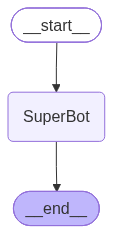

In [98]:
graph_builder=StateGraph(State)
##node
graph_builder.add_node("SuperBot",superbot)
##Edges
graph_builder.add_edge(START,"SuperBot")
graph_builder.add_edge("SuperBot",END)

graph=graph_builder.compile(checkpointer=memory)

#Display
display(Image(graph.get_graph().draw_mermaid_png()))

In [99]:
#Invocation
config={"configurable":{"thread_id":"1"}}
graph.invoke({'messages':"HI,my name is srikar and i like football"},config)

{'messages': [HumanMessage(content='HI,my name is srikar and i like football', additional_kwargs={}, response_metadata={}, id='31e5a280-de7d-4ca9-addd-acf359b0a007'),
  HumanMessage(content='HI,my name is srikar and i like football', additional_kwargs={}, response_metadata={}, id='e683e4f9-cb07-4ec2-9b6d-21e6b108c5e1'),
  AIMessage(content="Hi Srikar! It's great to meet you. Football is an exciting sport! Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1259, 'total_tokens': 1286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c980d3075f', 

In [101]:
#create a thread 
config={"configurable":{"thread_id":"3"}}
for chunk in graph.stream({"messages":"Hi,My name is Srikar i like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Srikar! It's great to meet you. Cricket is an exciting sport with a rich history. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1244, 'total_tokens': 1275, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c980d3075f', 'id': 'chatcmpl-EG0AK0FY7V90o6Ip8UKbA2qyFsQXg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02e43-cb1a-70e1-99d5-c802ac115479-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1244, 'output_tokens': 31, 'total_token

In [102]:
#create a thread 
config={"configurable":{"thread_id":"3"}}
for chunk in graph.stream({"messages":"Hi,My name is Srikar i like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Srikar i like cricket', additional_kwargs={}, response_metadata={}, id='a18cde16-e806-46e6-9453-b57e7545a801'), AIMessage(content="Hi Srikar! It's great to meet you. Cricket is an exciting sport with a rich history. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1244, 'total_tokens': 1275, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c980d3075f', 'id': 'chatcmpl-EG0AK0FY7V90o6Ip8UKbA2qyFsQXg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02e43-cb1a-7